In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)
import sys
# sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import mdata_utils 
import TCR_embedings

2026-05-18 13:27:00.443979: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-18 13:27:00.444373: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 13:27:00.510115: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-18 13:27:03.236697: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse

In [3]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/external/COMBAT paired T/"
filename = "common_HV200_atchEmb.h5mu"
DATA_PATH = path + filename

mdata_ori = mu.read(DATA_PATH)

In [34]:
mdata = mdata_ori.copy()
mdata

MuData object with n_obs × n_vars = 320152 × 4646
  obs:	'cloned', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	320152 x 4646
      obs:	'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'clone_id', 'clone_id_size', 'COMBAT_ID', 'scRNASeq_sample_ID', 'COMBAT_participant_timepoint_ID', 'Source', 'Age', 'Sex', 'Race', 'BMI', 'Hospitalstay', 'Death28', 'Institute', 'PreExistingHeartDisease', 'PreExistingLungDisease', 'PreExistingKidneyDisease', 'PreExistingDiabetes', 'PreExistingHypertension', 'PreExistingImmunocompromised', 'Smoking', 'Symptomatic', 'Requiredvasoactive', 'Respiratorysupport', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'Ethnicity', 'Tissue', 'DiseaseClassification', 'Pool_ID', 'Channel_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'Annotation_cell_type_colors', 'Annotation_major_subset_colors', 'Annotation_minor_subset_colors', 'Institute', 'ObjectCreateDate', 'Source_colors', 'Technology', 'X_umap_harmony', 'genome_annotation_version', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors_harmony', 'pca'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony', 'X_umap_source'
      varm:	'PCs'
      layers:	'raw', 'scaled'
      obsp:	'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	320152 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing'
      uns:	'chain_indices', 'scirpy_version'
      obsm:	'airr', 'chain_indices'

In [35]:
mdata['gex'].obs['Annotation_major_subset'].value_counts()

Annotation_major_subset
CD4       208036
CD8        81860
nan        19329
DP          4377
MAIT        3454
DN          2438
GDT          335
iNKT         319
NK             3
ncMono         1
Name: count, dtype: int64

In [36]:
#### subset on patient
# k = 10
# selected = np.random.choice(
#     mdata['gex'].obs['COMBAT_ID'].value_counts().index,
#     size=k,
#     replace=False
# ).tolist()
# mask = mdata['gex'].obs['COMBAT_ID'].isin(selected)
# mdata = mdata[mask].copy()


#### subset on disease
# mdata = mdata[mdata['gex'].obs['DiseaseClassification'].isin(['Sepsis;HP:0100806'])]


### subset on cell type
mdata = mdata[~mdata['gex'].obs['Annotation_major_subset'].isin(['MAIT', 'iNKT', 'GDT'])]

###
mdata = mdata[~mdata.obs['cloned']]

mdata

View of MuData object with n_obs × n_vars = 254428 × 4646
  obs:	'cloned', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	254428 x 4646
      obs:	'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'clone_id', 'clone_id_size', 'COMBAT_ID', 'scRNASeq_sample_ID', 'COMBAT_participant_timepoint_ID', 'Source', 'Age', 'Sex', 'Race', 'BMI', 'Hospitalstay', 'Death28', 'Institute', 'PreExistingHeartDisease', 'PreExistingLungDisease', 'PreExistingKidneyDisease', 'PreExistingDiabetes', 'PreExistingHypertension', 'PreExistingImmunocompromised', 'Smoking', 'Symptomatic', 'Requiredvasoactive', 'Respiratorysupport', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'Ethnicity', 'Tissue', 'DiseaseClassification', 'Pool_ID', 'Channel_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'Annotation_cell_type_colors', 'Annotation_major_subset_colors', 'Annotation_minor_subset_colors', 'Institute', 'ObjectCreateDate', 'Source_colors', 'Technology', 'X_umap_harmony', 'genome_annotation_version', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors_harmony', 'pca'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony', 'X_umap_source'
      varm:	'PCs'
      layers:	'raw', 'scaled'
      obsp:	'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	254428 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing'
      uns:	'chain_indices', 'scirpy_version'
      obsm:	'airr', 'chain_indices'

In [37]:
# subseting on single pair
mdata = mdata[mdata['airr'].obs['chain_pairing'].isin(['single pair'])]
# mdata = mdata[mdata['gex'].obs['COMBAT_ID'].astype(int) > 20]
mdata = mdata[~mdata['gex'].obs['Annotation_minor_subset'].isin(['nan', 'ncMono', 'DN', 'DP', 'NK.CD16hi', 'GDT.VD2neg'])]

# mdata = mdata_utils.sync_mdata_obs(mdata)
mdata

View of MuData object with n_obs × n_vars = 218623 × 4646
  obs:	'cloned', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	218623 x 4646
      obs:	'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'clone_id', 'clone_id_size', 'COMBAT_ID', 'scRNASeq_sample_ID', 'COMBAT_participant_timepoint_ID', 'Source', 'Age', 'Sex', 'Race', 'BMI', 'Hospitalstay', 'Death28', 'Institute', 'PreExistingHeartDisease', 'PreExistingLungDisease', 'PreExistingKidneyDisease', 'PreExistingDiabetes', 'PreExistingHypertension', 'PreExistingImmunocompromised', 'Smoking', 'Symptomatic', 'Requiredvasoactive', 'Respiratorysupport', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'Ethnicity', 'Tissue', 'DiseaseClassification', 'Pool_ID', 'Channel_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'Annotation_cell_type_colors', 'Annotation_major_subset_colors', 'Annotation_minor_subset_colors', 'Institute', 'ObjectCreateDate', 'Source_colors', 'Technology', 'X_umap_harmony', 'genome_annotation_version', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors_harmony', 'pca'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony', 'X_umap_source'
      varm:	'PCs'
      layers:	'raw', 'scaled'
      obsp:	'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	218623 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing'
      uns:	'chain_indices', 'scirpy_version'
      obsm:	'airr', 'chain_indices'

In [38]:
## select one cell from each clonotype
mdata['airr'].obs['clone_id_size'] = mdata['gex'].obs['clone_id_size'] 
mdata['airr'].obs['clone_id'] = mdata['gex'].obs['clone_id'] 

airr_obs = mdata['airr'].obs.copy()
clone_id_col = airr_obs['clone_id']
if hasattr(clone_id_col, 'cat'):
    clone_id_col = clone_id_col.astype(str)
airr_obs['_clone_id_str'] = clone_id_col

expanded = airr_obs[airr_obs['clone_id_size'] > 1].dropna(subset=['_clone_id_str'])
sampled_expanded_idx = (
    expanded
    .groupby('_clone_id_str', observed=True)
    .sample(n=1, random_state=42)
    .index
)

single_idx = airr_obs[airr_obs['clone_id_size'] == 1].index
keep_idx = sampled_expanded_idx.append(single_idx)

mdata = mdata[keep_idx].copy()
print(f"Expanded clones: {len(expanded)} cells -> {len(sampled_expanded_idx)} (1 per clone)")
print(f"Single clones: {len(single_idx)}")
print(f"Total after dedup: {mdata.n_obs} cells")


Expanded clones: 0 cells -> 0 (1 per clone)
Single clones: 218623
Total after dedup: 218623 cells


In [39]:
tcr_embs = mdata.obsm['tcr_embs']

#### no subsetteing  ####
view_gene = mdata['gex'].X
# view_gene = gex.X.toarray()

view_gene = np.asarray(view_gene, dtype=float)
view_tcr = np.asarray(tcr_embs, dtype=float)

scaler = StandardScaler()
# view_gene = scaler.fit_transform(view_gene)
# view_tcr = scaler.fit_transform(view_tcr)

from sklearn.decomposition import PCA
pca_gene = PCA(n_components=50, random_state=42)
view_gene_pca = pca_gene.fit_transform(view_gene)
var_explained = pca_gene.explained_variance_ratio_
view_gene = view_gene_pca

# print("GEX variance explained:", var_explained.cumsum())

In [40]:
# Check what view_gene actually contains
print("Mean expression:", view_gene.mean())
print("Max expression:", view_gene.max())
print("Sparsity:", (view_gene == 0).sum() / view_gene.size)

# Check variance per gene
gene_var = view_gene.var(axis=0)
print("Genes with near-zero variance:", (gene_var < 0.01).sum())
print("Variance distribution:")
print(np.percentile(gene_var, [25, 50, 75, 90, 95, 99]))

Mean expression: -2.5294449070978734e-14
Max expression: 64.75489168716771
Sparsity: 0.0
Genes with near-zero variance: 0
Variance distribution:
[ 1.10138461  1.24578648  2.33322851  4.26554854  7.72255854 18.87882061]


In [41]:
gex = mdata['gex']

# Check raw counts characteristics
import numpy as np

X = gex.X
if hasattr(X, 'toarray'):
    vals = X.toarray()
else:
    vals = np.asarray(X)

print("Min value:", vals.min())
print("Max value:", vals.max())
print("Mean value:", vals.mean())
print("Has non-integer values:", not np.all(vals == vals.astype(int)))
print("Sparsity:", (vals == 0).mean())

Min value: -5.075152142178875
Max value: 10.0
Mean value: -0.02293700373674818
Has non-integer values: True
Sparsity: 0.0


In [42]:
# # ── TCR side (optional) ──────────────────────────────────────────────
# pca_tcr = PCA(n_components=20, random_state=42)  # or keep all 244
# view_tcr_pca = pca_tcr.fit_transform(view_tcr)
# var_explained_tcr = pca_tcr.explained_variance_ratio_
# print("TCR variance explained:", var_explained_tcr.cumsum())


print(f"view_gene: {view_gene.shape} ")
print(f"view_tcr:  {view_tcr.shape}  ")

view_gene: (218623, 50) 
view_tcr:  (218623, 441)  


## CCA

In [43]:
### Train / test split + dataloaders ###
from sklearn.model_selection import train_test_split
mdata.obs['set'] = ''

train_frac = 0.7
dim_cca = min(view_gene.shape[1], view_tcr.shape[1], 5)

train_mask = np.random.rand(mdata.n_obs) < train_frac
test_mask = ~train_mask
mdata.obs.loc[train_mask, 'set'] = 'train'
mdata.obs.loc[test_mask, 'set'] = 'test'

view_gene_train = view_gene[train_mask]
view_gene_test = view_gene[test_mask]
view_tcr_train = view_tcr[train_mask]
view_tcr_test = view_tcr[test_mask]

print(f"Train: {view_gene_train.shape[0]}  Test: {view_gene_test.shape[0]}")
print(f"Latent dims (dim_cca): {dim_cca}")

Train: 152867  Test: 65756
Latent dims (dim_cca): 5


In [44]:
### Deep CCA: fit ###
sys.path.append(r"/ihome/ylee/yiz133/Code/Tools/")

# from cca_zoo.deep import DCCA, architectures
# from cca_zoo.deep.data import NumpyDataset, check_dataset, get_dataloaders
# import lightning.pytorch as pl

# LATENT_DIMS = dim_cca
# EPOCHS = 30
# BATCH_SIZE = 64

# train_dataset = NumpyDataset([view_gene_train, view_tcr_train])
# test_dataset = NumpyDataset([view_gene_test, view_tcr_test])

# train_loader = get_dataloaders(train_dataset, batch_size=BATCH_SIZE)
# test_loader = get_dataloaders(test_dataset, batch_size=BATCH_SIZE)

# encoder_1 = architectures.Encoder(
#     latent_dimensions=LATENT_DIMS, feature_size=view_gene_train.shape[1],
# )
# encoder_2 = architectures.Encoder(
#     latent_dimensions=LATENT_DIMS, feature_size=view_tcr_train.shape[1],
# )

# dcca = DCCA(latent_dimensions=LATENT_DIMS, encoders=[encoder_1, encoder_2])
# trainer = pl.Trainer(
#     max_epochs=EPOCHS,
#     enable_checkpointing=True,
#     enable_model_summary=True,
#     enable_progress_bar=True,
# )
# trainer.fit(dcca, train_loader)

# from torch.utils.data import DataLoader
# train_loader_full = DataLoader(NumpyDataset([view_gene_train, view_tcr_train]), batch_size=BATCH_SIZE, drop_last=False, shuffle=False)
# test_loader_full = DataLoader(NumpyDataset([view_gene_test, view_tcr_test]), batch_size=BATCH_SIZE, drop_last=False, shuffle=False)
# view_gene_c_train, view_tcr_c_train = cca.transform(train_loader_full)
# view_gene_c_test, view_tcr_c_test = cca.transform(test_loader_full)

In [45]:
# self CCA
dim_cca = 5
# cca = TCR_embedings.CCA(n_components=dim_cca) 
cca = TCR_embedings.rCCA(n_components=dim_cca, alpha_x=5, alpha_y=5,)

view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)
view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)

In [46]:
# Standardise canonical variates
        
# view_gene_c_train = scaler.fit_transform(view_gene_c_train)
# view_tcr_c_train = scaler.fit_transform(view_tcr_c_train)
# view_gene_c_test = scaler.fit_transform(view_gene_c_test)
# view_tcr_c_test = scaler.fit_transform(view_tcr_c_test)

# Combine into full-dataset arrays
view_gene_c = np.zeros((mdata.n_obs, dim_cca))
view_tcr_c = np.zeros((mdata.n_obs, dim_cca))
view_gene_c[train_mask] = view_gene_c_train
view_gene_c[test_mask] = view_gene_c_test
view_tcr_c[train_mask] = view_tcr_c_train
view_tcr_c[test_mask] = view_tcr_c_test

# Store canonical variate scores in mdata
for i in range(dim_cca):
    mdata['gex'].obs[f'DCCA_CV_{i}'] = view_gene_c[:, i]
    mdata['gex'].obs[f'DCCA_CV_TCR_{i}'] = view_tcr_c[:, i]

# Per-component correlations
print("Per-component correlations (train / test):")
for i in range(dim_cca):
    r_tr = np.corrcoef(view_gene_c_train[:, i], view_tcr_c_train[:, i])[0, 1]
    r_te = np.corrcoef(view_gene_c_test[:, i], view_tcr_c_test[:, i])[0, 1]
    print(f"  CC {i}: train {r_tr:.4f}  test {r_te:.4f}")

print(f"\nTrain canonical variates shape: {view_gene_c_train.shape}")
print(f"Test canonical variates shape:  {view_gene_c_test.shape}")

Per-component correlations (train / test):
  CC 0: train 0.3098  test 0.3147
  CC 1: train 0.1070  test 0.0881
  CC 2: train 0.0972  test 0.0864
  CC 3: train 0.0865  test 0.0586
  CC 4: train 0.0815  test 0.0533

Train canonical variates shape: (152867, 5)
Test canonical variates shape:  (65756, 5)


In [47]:
cv_list = []
for i in range(view_gene_c_train.shape[1]):
    mdata['gex'].obs['CV_score_'+str(i)] = view_tcr_c[:, i]
    cv_list.append('CV_score_'+str(i))
    

In [48]:
view_gene_c_test.shape

(65756, 5)

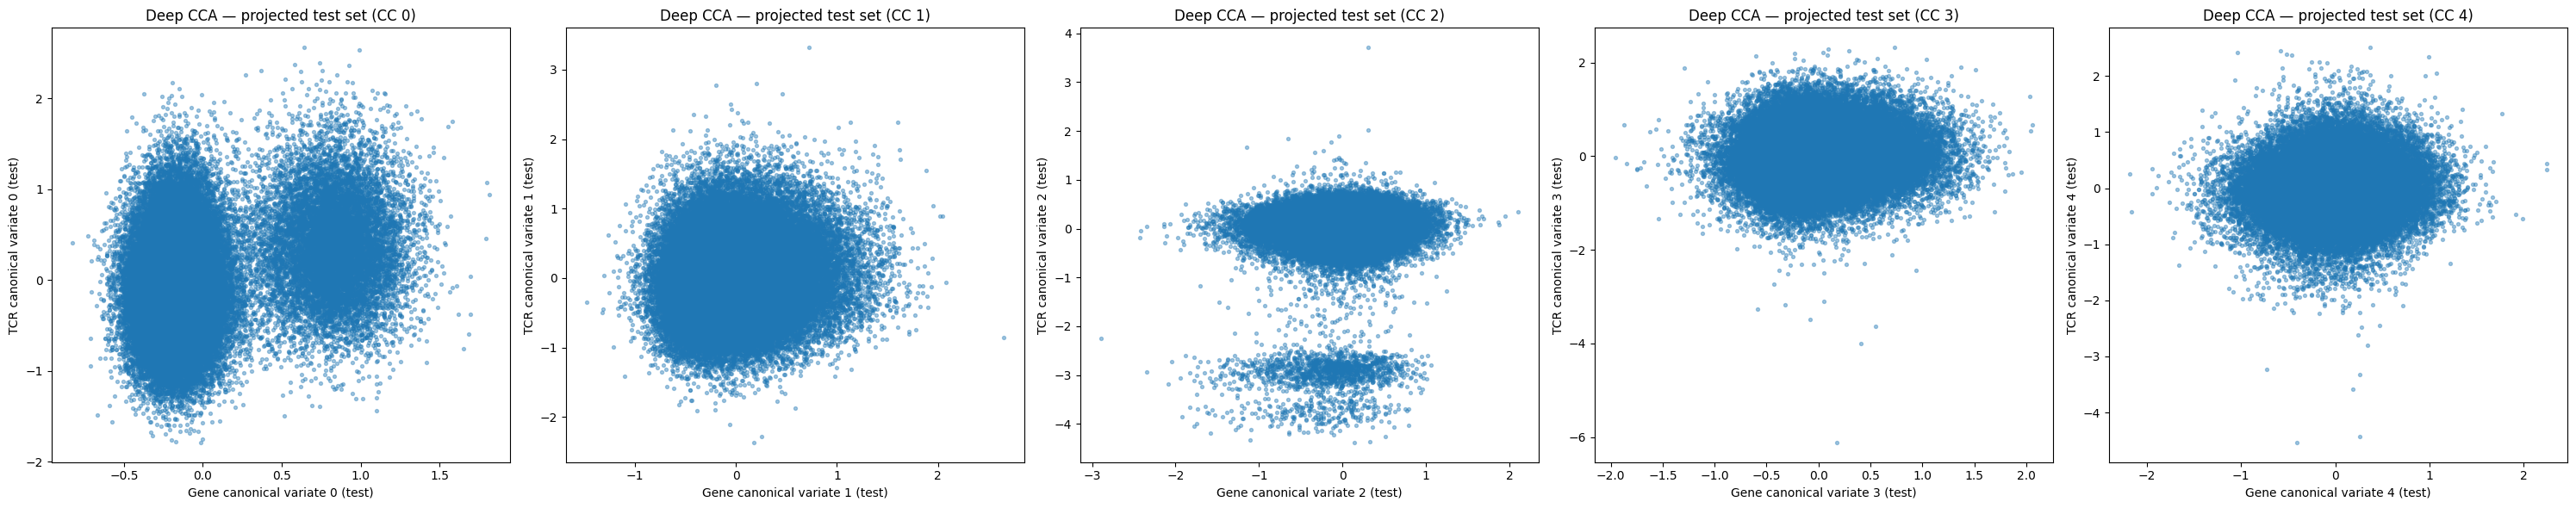

In [49]:
fig, axes = plt.subplots(1, dim_cca, figsize=(6 * dim_cca, 6))
if dim_cca == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.scatter(
        view_gene_c_test[:, i], view_tcr_c_test[:, i],
        alpha=0.4, s=8,
    )
    ax.set_xlabel(f'Gene canonical variate {i} (test)')
    ax.set_ylabel(f'TCR canonical variate {i} (test)')
    ax.set_title(f'Deep CCA — projected test set (CC {i})')

plt.tight_layout()
plt.show()

In [50]:
mdata

MuData object with n_obs × n_vars = 218623 × 4646
  obs:	'cloned', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length', 'set'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	218623 x 4646
      obs:	'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'clone_id', 'clone_id_size', 'COMBAT_ID', 'scRNASeq_sample_ID', 'COMBAT_participant_timepoint_ID', 'Source', 'Age', 'Sex', 'Race', 'BMI', 'Hospitalstay', 'Death28', 'Institute', 'PreExistingHeartDisease', 'PreExistingLungDisease', 'PreExistingKidneyDisease', 'PreExistingDiabetes', 'PreExistingHypertension', 'PreExistingImmunocompromised', 'Smoking', 'Symptomatic', 'Requiredvasoactive', 'Respiratorysupport', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'Ethnicity', 'Tissue', 'DiseaseClassification', 'Pool_ID', 'Channel_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'DCCA_CV_0', 'DCCA_CV_TCR_0', 'DCCA_CV_1', 'DCCA_CV_TCR_1', 'DCCA_CV_2', 'DCCA_CV_TCR_2', 'DCCA_CV_3', 'DCCA_CV_TCR_3', 'DCCA_CV_4', 'DCCA_CV_TCR_4', 'CV_score_0', 'CV_score_1', 'CV_score_2', 'CV_score_3', 'CV_score_4'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'Annotation_cell_type_colors', 'Annotation_major_subset_colors', 'Annotation_minor_subset_colors', 'Institute', 'ObjectCreateDate', 'Source_colors', 'Technology', 'X_umap_harmony', 'genome_annotation_version', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors_harmony', 'pca'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony', 'X_umap_source'
      varm:	'PCs'
      layers:	'raw', 'scaled'
      obsp:	'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	218623 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id_size', 'clone_id'
      uns:	'chain_indices', 'scirpy_version'
      obsm:	'airr', 'chain_indices'

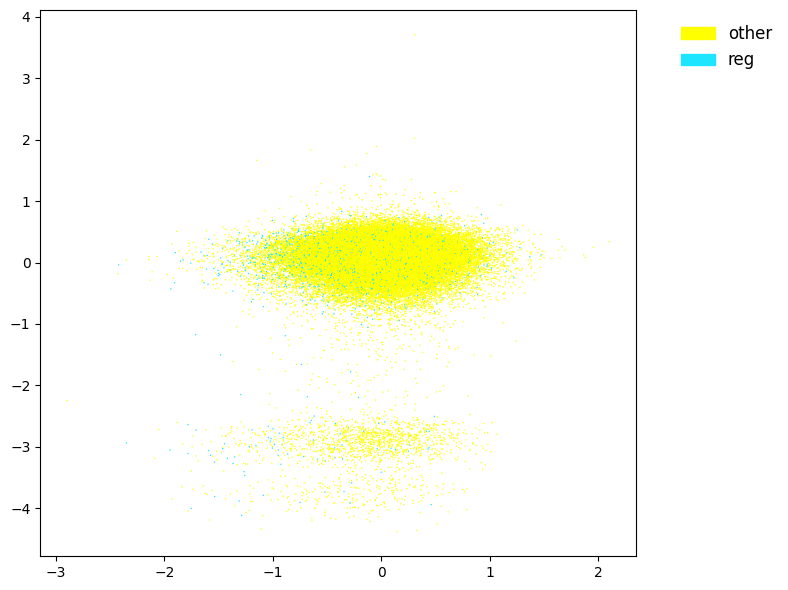

In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def classify_annotation(label):
    if 'REG' in str(label).upper():
        return 'reg'
    # elif any(x in str(label).upper() for x in ['CM', 'EM']):
    #     return 'MEM'
    else:
        return 'other'

mdata['gex'].obs['T_subset'] = (
    mdata['gex'].obs['Annotation_minor_subset']
    .apply(classify_annotation)
    .astype('category')
)


# Get categories and assign colors
# Annotation_minor_subset
obs_select = 'T_subset'
cats = mdata['gex'].obs[obs_select][test_mask].cat.categories
palette = dict(zip(cats, sc.pl.palettes.default_102[:len(cats)]))
colors = mdata['gex'].obs[obs_select][test_mask].map(palette)

# Get UMAP coordinates
fig, ax = plt.subplots(figsize=(8, 6))

i = 2
ax.scatter(
    view_gene_c_test[:, i], view_tcr_c_test[:, i],
    c=colors,
    linewidths=0,
    s = 1
)

# Legend
handles = [mpatches.Patch(color=palette[cat], label=cat) for cat in cats]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

In [52]:
corr_train, corr_test = TCR_embedings.train_test_corr(view_gene_c_train, view_tcr_c_train, view_gene_c_test, view_tcr_c_test)

Canonical Correlations Comparison:
Component       Train Corr      Test Corr       Difference     
Component 1      0.3098          0.3147          -0.0049        
Component 2      0.1070          0.0881          0.0189         
Component 3      0.0972          0.0864          0.0107         
Component 4      0.0865          0.0586          0.0280         
Component 5      0.0815          0.0533          0.0282         


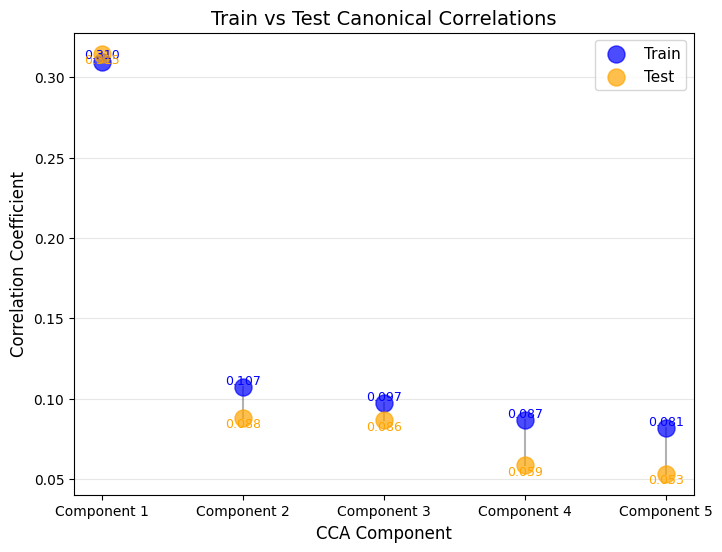

In [53]:
ax = TCR_embedings.plot_train_test_corr(corr_train, corr_test)
# ax.set_ylim(0, 1)

In [54]:
mdata['gex'].obs['Annotation_minor_subset'] = (
    mdata['gex'].obs['Annotation_minor_subset']
    .cat.remove_unused_categories()
)

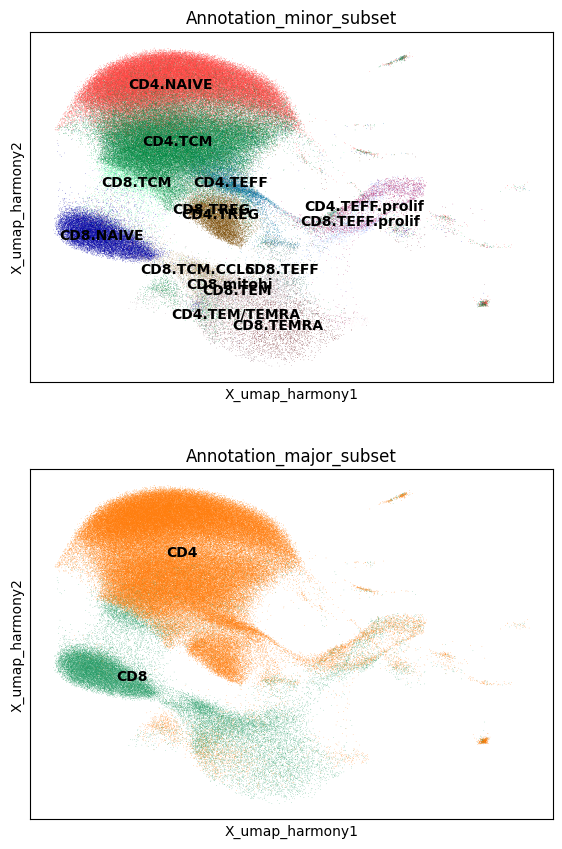

In [55]:
cols = [c for c in (
    'Annotation_minor_subset',
    'Annotation_major_subset',
) if c in mdata['gex'].obs]

sc.pl.embedding(mdata['gex'], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', legend_loc='on data',
                color=cols, ncols=1, )


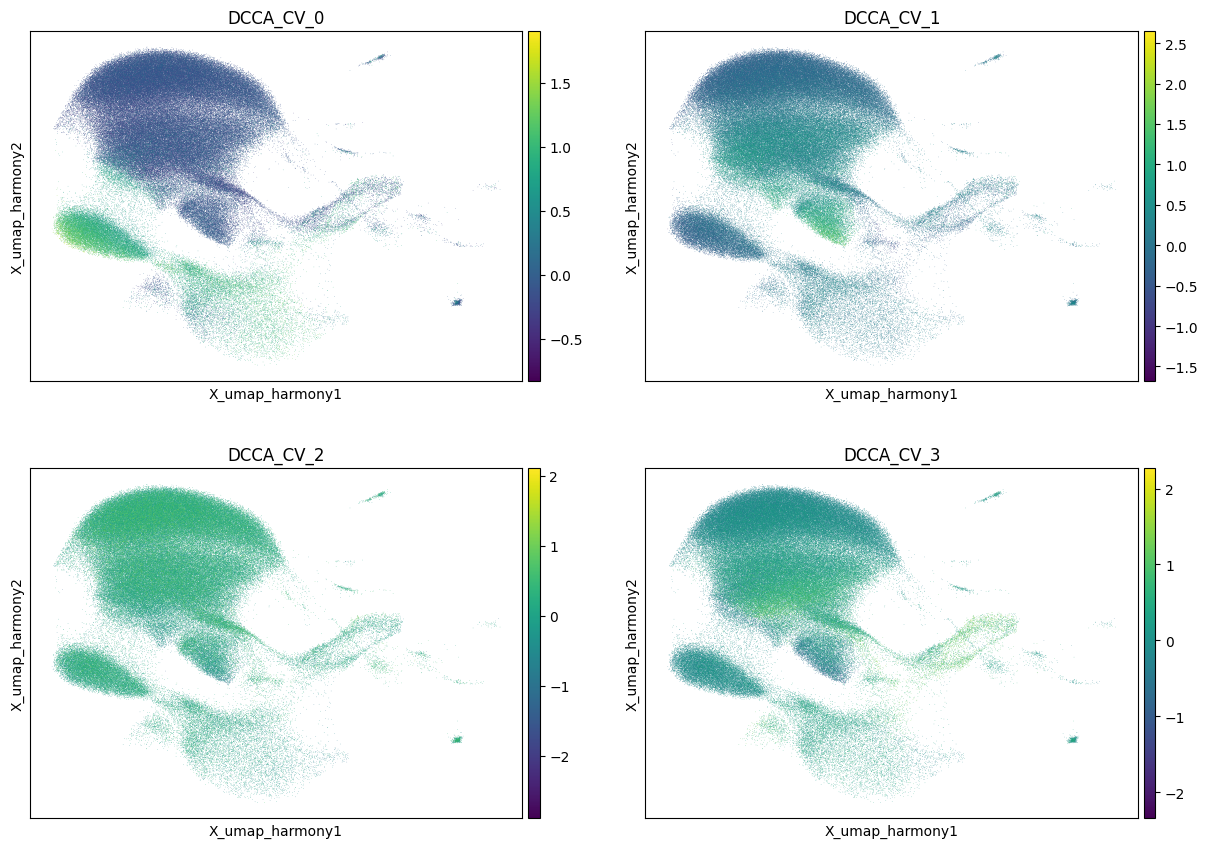

In [56]:
cols = [c for c in (
    'DCCA_CV_0',
    'DCCA_CV_1',
    'DCCA_CV_2',
    'DCCA_CV_3',
    
) if c in mdata['gex'].obs]

sc.pl.embedding(mdata['gex'], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
                color=cols, ncols=2)

### CV Alignment visualize

In [57]:
from scipy.stats import kruskal, pointbiserialr
import pandas as pd

composition_cols = ['Annotation_minor_subset',
    'Annotation_major_subset',
                    'DiseaseClassification'
                   ]
records = []

# CV_from = "DCCA_CV_"
CV_from = "DCCA_CV_TCR_"

for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()
    idx = scores.index

    for c in composition_cols:
        cats = mdata['gex'].obs.loc[idx, c].dropna()
        shared_idx = scores.index.intersection(cats.index)
        s = scores.loc[shared_idx]
        g = cats.loc[shared_idx]

        unique_cats = g.unique()

        if len(unique_cats) == 2:
            # binary → point-biserial r
            binary = (g == unique_cats[0]).astype(int)
            r, p = pointbiserialr(binary, s)
            records.append(dict(cv=col, obs_col=c, test='pointbiserial',
                                statistic=r, pval=p, categories=list(unique_cats)))

        elif len(unique_cats) > 2:
            # multi-category → Kruskal-Wallis H
            groups = [s[g == cat].values for cat in unique_cats]
            groups = [g for g in groups if len(g) > 1]
            if len(groups) >= 2:
                H, p = kruskal(*groups)
                records.append(dict(cv=col, obs_col=c, test='kruskal',
                                    statistic=H, pval=p, categories=list(unique_cats)))

df_stats = pd.DataFrame(records)

# FDR correction
from statsmodels.stats.multitest import multipletests
_, df_stats['pval_fdr'], _, _ = multipletests(df_stats['pval'], method='fdr_bh')
df_stats = df_stats.sort_values(['cv', 'pval_fdr'])

print(df_stats[['cv', 'obs_col', 'test', 'statistic', 'pval', 'pval_fdr']])

               cv                  obs_col           test     statistic  \
0   DCCA_CV_TCR_0  Annotation_minor_subset        kruskal  21602.997633   
1   DCCA_CV_TCR_0  Annotation_major_subset  pointbiserial     -0.330755   
2   DCCA_CV_TCR_0    DiseaseClassification        kruskal     21.634807   
3   DCCA_CV_TCR_1  Annotation_minor_subset        kruskal   1183.034135   
5   DCCA_CV_TCR_1    DiseaseClassification        kruskal     91.231065   
4   DCCA_CV_TCR_1  Annotation_major_subset  pointbiserial      0.007155   
6   DCCA_CV_TCR_2  Annotation_minor_subset        kruskal    595.961640   
8   DCCA_CV_TCR_2    DiseaseClassification        kruskal     81.969249   
7   DCCA_CV_TCR_2  Annotation_major_subset  pointbiserial      0.008657   
9   DCCA_CV_TCR_3  Annotation_minor_subset        kruskal    405.425273   
11  DCCA_CV_TCR_3    DiseaseClassification        kruskal     68.463208   
10  DCCA_CV_TCR_3  Annotation_major_subset  pointbiserial     -0.003891   
14  DCCA_CV_TCR_4    Dise

In [58]:
from scipy.stats import spearmanr

records_cat = []

for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    for c in composition_cols:
        cats = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(cats.index)

        for cat_val in cats.loc[shared].unique():
            binary = (cats.loc[shared] == cat_val).astype(int)
            r, p = spearmanr(scores.loc[shared], binary)
            records_cat.append(dict(cv=col, obs_col=c, category=cat_val,
                                    spearman_r=r, pval=p))

df_cat = pd.DataFrame(records_cat)
_, df_cat['pval_fdr'], _, _ = multipletests(df_cat['pval'], method='fdr_bh')
df_cat = df_cat.sort_values('spearman_r', key=abs, ascending=False)
print(df_cat.head(20))

                cv                  obs_col                category  \
15   DCCA_CV_TCR_0  Annotation_major_subset                     CD4   
16   DCCA_CV_TCR_0  Annotation_major_subset                     CD8   
2    DCCA_CV_TCR_0  Annotation_minor_subset               CD8.NAIVE   
1    DCCA_CV_TCR_0  Annotation_minor_subset               CD4.NAIVE   
11   DCCA_CV_TCR_0  Annotation_minor_subset                 CD8.TCM   
0    DCCA_CV_TCR_0  Annotation_minor_subset                 CD4.TCM   
3    DCCA_CV_TCR_0  Annotation_minor_subset                 CD8.TEM   
8    DCCA_CV_TCR_0  Annotation_minor_subset            CD8.TCM.CCL5   
10   DCCA_CV_TCR_0  Annotation_minor_subset               CD8.TEMRA   
12   DCCA_CV_TCR_0  Annotation_minor_subset         CD8.TEFF.prolif   
22   DCCA_CV_TCR_1  Annotation_minor_subset               CD4.NAIVE   
13   DCCA_CV_TCR_0  Annotation_minor_subset              CD8.mitohi   
103  DCCA_CV_TCR_4    DiseaseClassification                      NA   
9    D

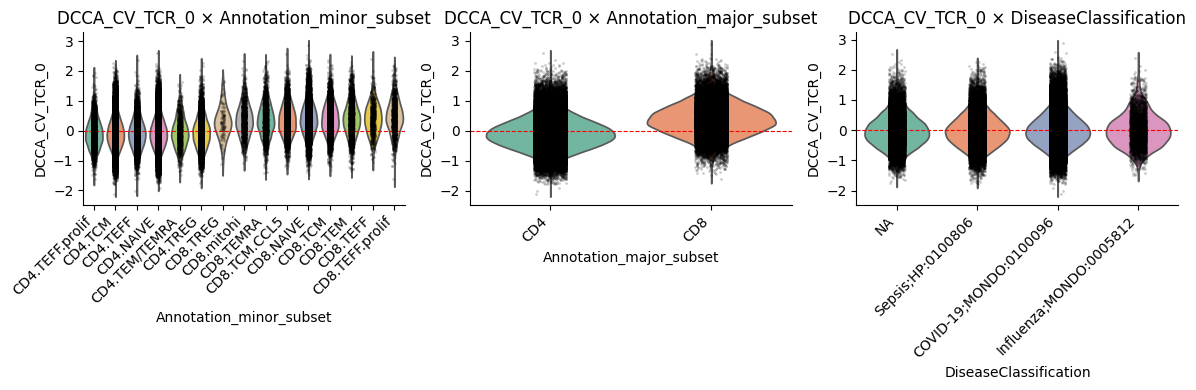

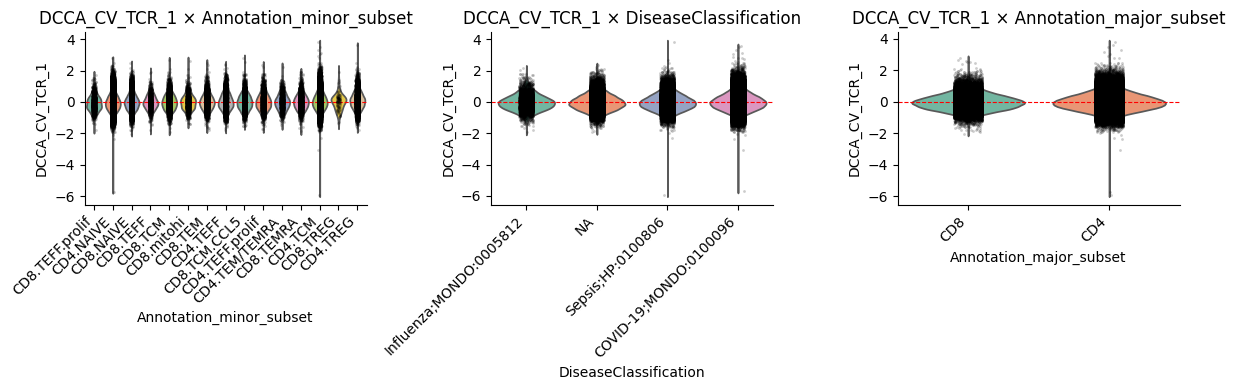

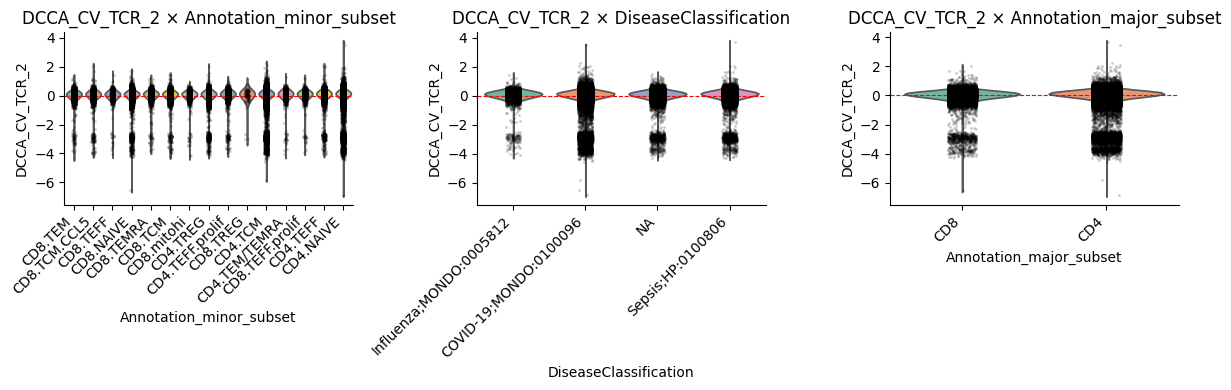

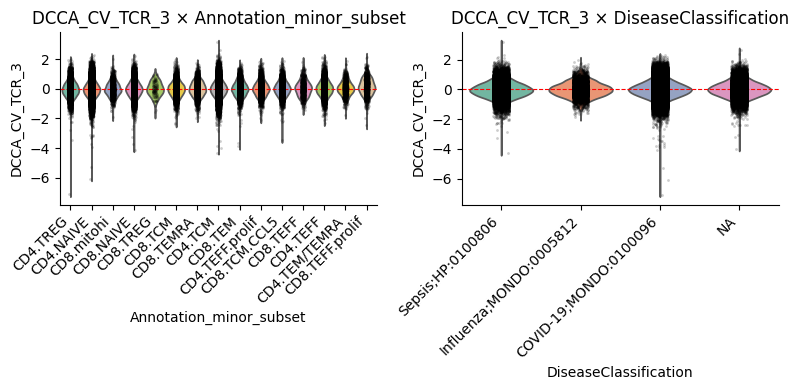

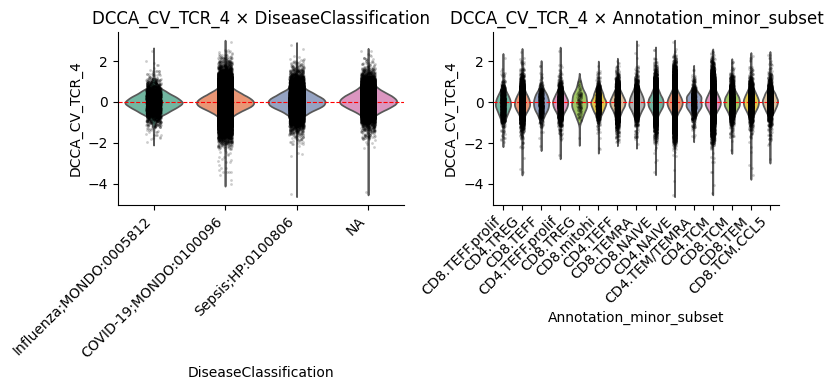

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# pick significant columns per CV from df_stats
sig = df_stats[df_stats['pval_fdr'] < 0.05]

for i in range(dim_cca):
    col = CV_from + str(i)
    sig_cols = sig[sig['cv'] == col]['obs_col'].tolist()

    if not sig_cols:
        continue

    fig, axes = plt.subplots(1, len(sig_cols), figsize=(4 * len(sig_cols), 4))
    if len(sig_cols) == 1:
        axes = [axes]

    for ax, c in zip(axes, sig_cols):
        plot_df = mdata['gex'].obs[[col, c]].dropna()
        order = plot_df.groupby(c)[col].median().sort_values().index

        sns.violinplot(data=plot_df, x=c, y=col, order=order,
                       inner=None, palette='Set2', ax=ax)
        sns.stripplot(data=plot_df, x=c, y=col, order=order,
                      color='black', alpha=0.2, size=2, ax=ax)
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
        ax.set_title(f'{col} × {c}')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    # plt.savefig(f'{col}_category_association.pdf', bbox_inches='tight')
    plt.show()

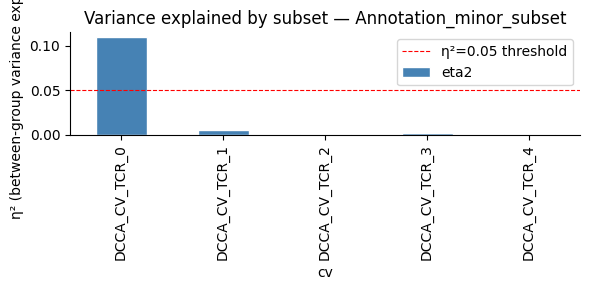

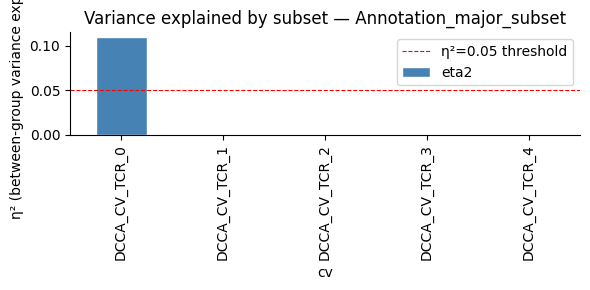

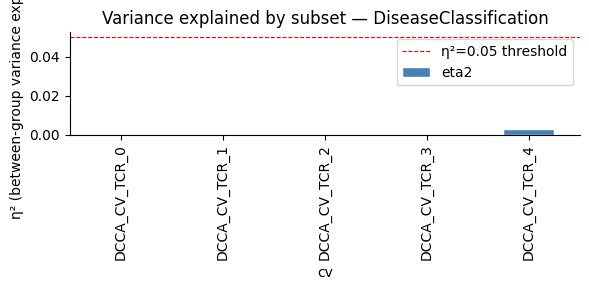

In [60]:
# 1. variance explained by each CV across subsets
#    = between-group variance / total variance per CV

records_var = []
for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()
    total_var = scores.var()

    for c in composition_cols:
        labels = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(labels.index)

        group_means = scores.loc[shared].groupby(labels.loc[shared]).mean()
        grand_mean  = scores.loc[shared].mean()

        # between-group variance (eta squared)
        between_var = (
            labels.loc[shared].value_counts() *
            (group_means - grand_mean) ** 2
        ).sum() / len(shared)

        eta2 = between_var / total_var

        records_var.append(dict(cv=col, obs_col=c, eta2=eta2))

df_var = pd.DataFrame(records_var)

# plot eta2 per CV per obs column
for c in composition_cols:
    sub = df_var[df_var['obs_col'] == c].set_index('cv')['eta2']
    fig, ax = plt.subplots(figsize=(6, 3))
    sub.plot.bar(ax=ax, color='steelblue', edgecolor='white')
    ax.set_ylabel('η² (between-group variance explained)')
    ax.set_title(f'Variance explained by subset — {c}')
    ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8,
               label='η²=0.05 threshold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'eta2_{c}.pdf', bbox_inches='tight')
    plt.show()

### one vs rest

In [64]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

records_ovr = []

for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    # only run on columns that passed Step 1 FDR
    sig_cols = df_stats[
        (df_stats['cv'] == col) & (df_stats['pval_fdr'] < 0.05)
    ]['obs_col'].tolist()

    for c in sig_cols:
        labels = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(labels.index)
        s = scores.loc[shared]
        g = labels.loc[shared]

        for cat_val in g.unique():
            in_group  = s[g == cat_val].values
            out_group = s[g != cat_val].values  # all rest

            if len(in_group) < 3 or len(out_group) < 3:
                continue

            U, p = mannwhitneyu(in_group, out_group, alternative='two-sided')

            # rank-biserial correlation as effect size
            rbc = 1 - (2 * U) / (len(in_group) * len(out_group))

            # median difference
            median_diff = np.median(in_group) - np.median(out_group)

            records_ovr.append(dict(
                cv          = col,
                obs_col     = c,
                category    = cat_val,
                n_in        = len(in_group),
                n_out       = len(out_group),
                U           = U,
                rbc         = rbc,
                median_diff = median_diff,
                pval        = p,
            ))

df_ovr = pd.DataFrame(records_ovr)
_, df_ovr['pval_fdr'], _, _ = multipletests(df_ovr['pval'], method='fdr_bh')
df_ovr = df_ovr.sort_values(['cv', 'pval_fdr'])

print(df_ovr[df_ovr['pval_fdr'] < 0.05])

               cv                  obs_col         category   n_in   n_out  \
0   DCCA_CV_TCR_0  Annotation_minor_subset          CD4.TCM  73696  144927   
1   DCCA_CV_TCR_0  Annotation_minor_subset        CD4.NAIVE  86472  132151   
2   DCCA_CV_TCR_0  Annotation_minor_subset        CD8.NAIVE  18252  200371   
3   DCCA_CV_TCR_0  Annotation_minor_subset          CD8.TEM   3729  214894   
8   DCCA_CV_TCR_0  Annotation_minor_subset     CD8.TCM.CCL5   3773  214850   
..            ...                      ...              ...    ...     ...   
94  DCCA_CV_TCR_4  Annotation_minor_subset     CD8.TCM.CCL5   3773  214850   
93  DCCA_CV_TCR_4  Annotation_minor_subset  CD4.TEFF.prolif   2795  215828   
91  DCCA_CV_TCR_4  Annotation_minor_subset         CD4.TEFF   7296  211327   
95  DCCA_CV_TCR_4  Annotation_minor_subset         CD8.TEFF    852  217771   
89  DCCA_CV_TCR_4  Annotation_minor_subset          CD8.TEM   3729  214894   

               U       rbc  median_diff      pval  pval_fdr  
0

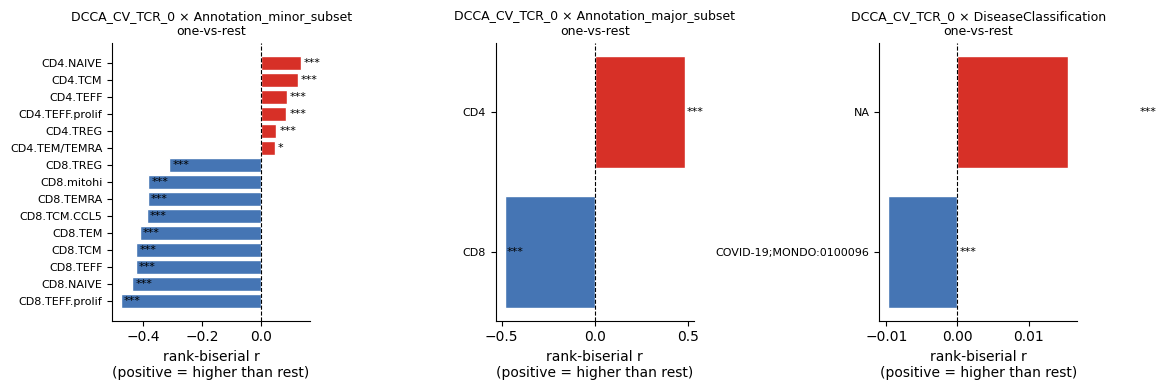

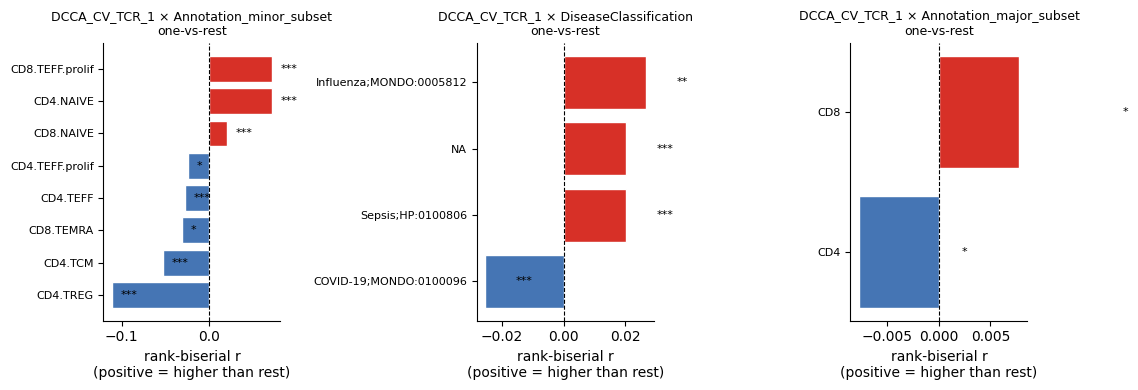

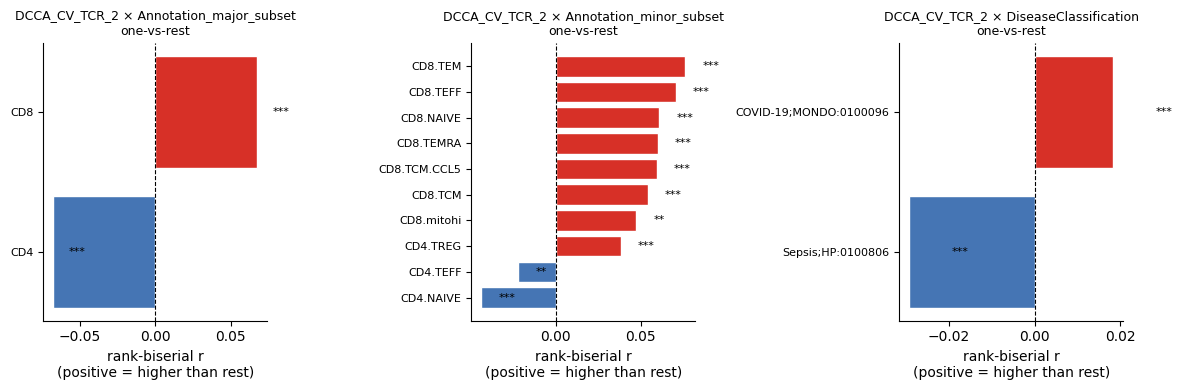

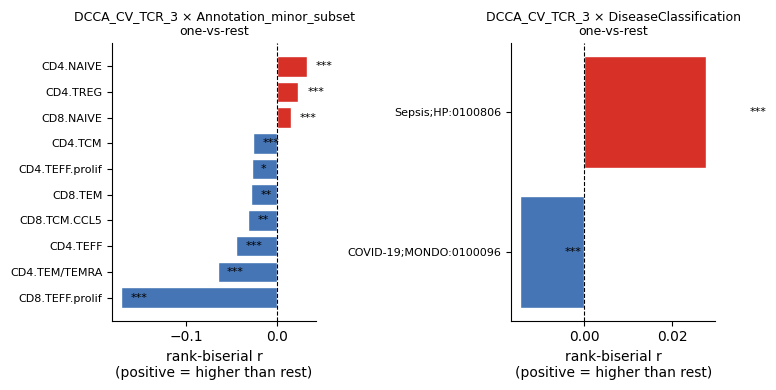

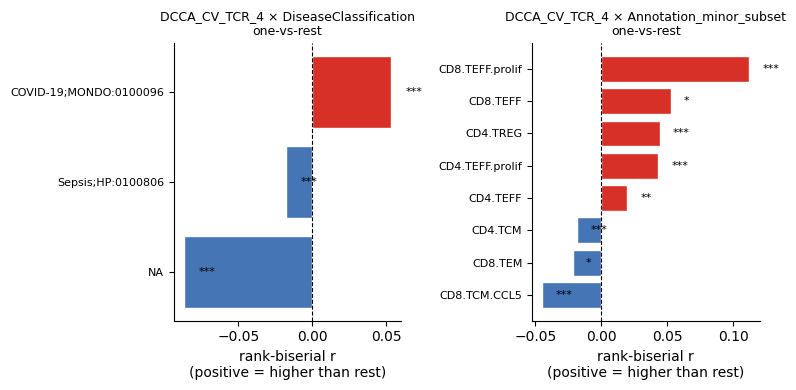

In [65]:
for i in range(dim_cca):
    col = CV_from + str(i)
    sub = df_ovr[
        (df_ovr['cv'] == col) & (df_ovr['pval_fdr'] < 0.05)
    ]

    if sub.empty:
        continue

    sig_cols = sub['obs_col'].unique()
    fig, axes = plt.subplots(1, len(sig_cols),
                              figsize=(4 * len(sig_cols), 4))
    if len(sig_cols) == 1:
        axes = [axes]

    for ax, c in zip(axes, sig_cols):
        plot_df = sub[sub['obs_col'] == c].sort_values('rbc')

        colors = ['#d73027' if v > 0 else '#4575b4'
                  for v in plot_df['rbc']]

        ax.barh(range(len(plot_df)), plot_df['rbc'],
                color=colors, edgecolor='white')
        ax.set_yticks(range(len(plot_df)))
        ax.set_yticklabels(plot_df['category'], fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('rank-biserial r\n(positive = higher than rest)')
        ax.set_title(f'{col} × {c}\none-vs-rest', fontsize=9)

        # mark FDR significance
        for j, (_, row) in enumerate(plot_df.iterrows()):
            stars = ('***' if row.pval_fdr < 0.001 else
                     '**'  if row.pval_fdr < 0.01  else
                     '*'   if row.pval_fdr < 0.05  else '')
            ax.text(row.rbc + 0.01, j, stars, va='center', fontsize=8)

        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{col}_ovr.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
aa

## logit regression

In [ ]:
### Logistic Regression per subtype: predict clone_status using DCCA canonical variates ###
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from imblearn.over_sampling import RandomOverSampler
import torch
import torch.nn as nn

tg = obs_select
g1, g2 = tg[0], tg[1]

cs = obs_select
sub = mdata.obs['Annotation_minor_subset']
in_groups = np.isin(cs, tg)

y_all = (cs == g1).astype(int)

subtypes = sorted(set(sub[in_groups]))

class WeightedLogistic(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.feature_weights = nn.Parameter(torch.ones(n_features))
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x * self.feature_weights).squeeze(-1)

lr_results = []

for st in subtypes:
    st_mask = sub == st
    mask_tr = train_mask & in_groups & st_mask
    mask_te = test_mask & in_groups & st_mask

    X_tr = view_tcr_c[mask_tr]
    X_te = view_tcr_c[mask_te]
    y_tr = y_all[mask_tr]
    y_te = y_all[mask_te]

    if X_tr.shape[0] < 10 or X_te.shape[0] < 4:
        continue
    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
        continue

    ros = RandomOverSampler(random_state=42)
    X_tr_bal, y_tr_bal = ros.fit_resample(X_tr, y_tr)

    # Trainable-weight logistic
    wlr_epochs = 200
    X_tr_t = torch.tensor(X_tr_bal, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_bal, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)

    wlr = WeightedLogistic(X_tr_t.shape[1])
    optimizer = torch.optim.Adam(wlr.parameters(), lr=1e-2)
    loss_fn = nn.BCEWithLogitsLoss()

    wlr.train()
    for epoch in range(wlr_epochs):
        optimizer.zero_grad()
        loss_fn(wlr(X_tr_t), y_tr_t).backward()
        optimizer.step()

    wlr.eval()
    with torch.no_grad():
        y_pred_proba = torch.sigmoid(wlr(X_te_t)).numpy()
        y_pred = (y_pred_proba >= 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    try:
        auc = roc_auc_score(y_te, y_pred_proba)
    except ValueError:
        auc = np.nan

    learned_w = wlr.feature_weights.detach().numpy()

    lr_results.append({
        'subtype': st,
        'n_train': X_tr_bal.shape[0],
        'n_test': X_te.shape[0],
        'accuracy': acc,
        'roc_auc': auc,
        'feature_weights': learned_w.tolist(),
    })

    print(f"\n{'='*60}")
    print(f"Subtype: {st}  (train={X_tr_bal.shape[0]}, test={X_te.shape[0]})")
    print(f"{'='*60}")
    print(f"Feature weights: {learned_w}")
    print(f"Accuracy: {acc:.4f}   ROC AUC: {auc:.4f}")
    print(classification_report(y_te, y_pred, target_names=[g2, g1], zero_division=0))

lr_results_df = pd.DataFrame(lr_results)
lr_results_df
